# sklearn model with tensorflow keras tuner

In [1]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
import re
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
from textstat import flesch_reading_ease, gunning_fog
import numpy as np

# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('stopwords')
# nltk.download('vader_lexicon')

def extract_and_aggregate_features(df, text_column):
    """Extracts and aggregates features at the paragraph, sentence, and word levels."""
    # Processing text into paragraphs, sentences, and words
    df['paragraph_lengths'] = df[text_column].apply(lambda x: [len(p.split()) for p in x.split('\n\n') if p.strip()])
    df['sentence_lengths'] = df[text_column].apply(lambda x: [len(s.split()) for s in nltk.sent_tokenize(x)])
    df['word_lengths'] = df[text_column].apply(lambda x: [len(w) for w in x.split()])

    # Aggregating features
    df['paragraph_count'] = df['paragraph_lengths'].apply(len)
    df['sentence_count'] = df['sentence_lengths'].apply(len)
    df['word_count'] = df['word_lengths'].apply(len)

    df['avg_paragraph_length'] = df['paragraph_lengths'].apply(np.mean)
    df['max_paragraph_length'] = df['paragraph_lengths'].apply(max)
    df['min_paragraph_length'] = df['paragraph_lengths'].apply(min)

    df['avg_sentence_length'] = df['sentence_lengths'].apply(np.mean)
    df['max_sentence_length'] = df['sentence_lengths'].apply(max)
    df['min_sentence_length'] = df['sentence_lengths'].apply(min)

    df['avg_word_length'] = df['word_lengths'].apply(np.mean)
    df['max_word_length'] = df['word_lengths'].apply(max)
    df['min_word_length'] = df['word_lengths'].apply(min)

    # Cleaning up DataFrame to remove list columns
    df.drop(['paragraph_lengths', 'sentence_lengths', 'word_lengths'], axis=1, inplace=True)

    return df

def compute_readability_and_sentiment(df, text_column):
    """Computes readability scores and sentiment analysis."""
    df['flesch_reading_ease'] = df[text_column].apply(flesch_reading_ease)
    df['gunning_fog_index'] = df[text_column].apply(gunning_fog)
    sia = SentimentIntensityAnalyzer()
    df['sentiment_score'] = df[text_column].apply(lambda x: sia.polarity_scores(x)['compound'])

    return df


def add_text_features(df, text_column):
    """Main function to aggregate all text processing and feature extraction steps."""
    tqdm.pandas(desc="Extracting and aggregating text features")
    df = extract_and_aggregate_features(df, text_column)
    df = compute_readability_and_sentiment(df, text_column)


    
    return df    

In [3]:

import wordninja
from nltk.corpus import words

# Load a set of valid English words from NLTK for verification (if needed)
word_list = set(words.words())

def segment_text(text, word_list=word_list):
    """
    Segments concatenated words using wordninja, verifying segmentation with an NLTK words list.

    Args:
    text (str): A string of concatenated words.
    word_list (set): A set containing valid words.

    Returns:
    str: Segmented text, or the original text if segmentation results in less common words.
    """
    segmented_words = wordninja.split(text)
    segmented_text = ' '.join(segmented_words)

    # Optional: verify if the original text is a valid word and if the segmented version introduces less common words
    if text in word_list and not all(word in word_list for word in segmented_words):
        return text
    else:
        return segmented_text



def apply_segmentation(df_chunk, text_col='clean_text'):
    """
    Applies text segmentation to the specified 'text' column of a DataFrame chunk using wordninja.

    Args:
    df_chunk (pd.DataFrame): DataFrame chunk containing a text column with concatenated words.

    Returns:
    pd.DataFrame: DataFrame chunk with a new column 'segmented_text' containing segmented text.
    """
    df_chunk['clean_text'] = df_chunk[text_col].apply(lambda x: segment_text(x))
    return df_chunk

In [4]:
def clean_text(df, col_name = 'full_text'):
    """
    Preprocesses text for both training and testing datasets. 
    Includes loading embeddings, building vocabularies, cleaning text among other things.
    
    :param summaries_train: DataFrame with the training data
    :param summaries_test: DataFrame with the testing data
    :param glove_path: path to the GloVe embedding
    :param paragram_path: path to the Paragram embedding
    :param wiki_news_path: path to the Wiki News embedding
    
    :return: Preprocessed DataFrame and list of out-of-vocab words
    """
    print("Starting text cleaning process. \n")

    
    # Lowercase all texts

    df['lowered'] = df[col_name].apply(lambda x: x.lower())

    
    
    def clean_spacing(text):
        
        # Remove spaces before punctuation
        text = re.sub(r'\s+([,.!?])', r'\1', text)

        # Ensure there is one space after punctuation
        text = re.sub(r'([,.!?])([^\s])', r'\1 \2', text)

        return text
    

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


        
    punct = "/-'?!.,#$%\'()*+-/:;<=>@[\\]^_`{|}~" + '""“”’' + '∞θ÷α•à−β∅³π‘₹´°£€\×™√²—–&'
    
    punct_mapping = {"‘": "'", "₹": "e", "´": "'", "°": "", "€": "e", "™": "tm", "√": " sqrt ", "×": "x", "²": "2", "—": "-", "–": "-", "’": "'", "_": "-",
                     "`": "'", '“': '"', '”': '"', '“': '"', "£": "e", '∞': 'infinity', 'θ': 'theta', '÷': '/', 'α': 'alpha', '•': '.', 'à': 'a', '−': '-', 
                     'β': 'beta', '∅': '', '³': '3', 'π': 'pi', }

    def clean_special_chars(text, punct, mapping):
        for p in mapping:
            text = text.replace(p, mapping[p])
        for p in punct:
            text = text.replace(p, f' {p} ')
        specials = {'\u200b': ' ', '…': ' ... ', '\ufeff': '', 'करना': '', 'है': ''}  
        for s in specials:
            text = text.replace(s, specials[s])
        return text
    

    df['clean_text'] = df['clean_text'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


    cont_map = {
        "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have",
        "couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not",
        "hadn't've": "had not have","hasn't": "has not",
        "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
        "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will",
        "I'll've": "I will have","I'm": "I am","I've": "I have",
        "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us",
        "ma'am": "madam","mayn't": "may not",
        "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not",
        "mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not",
        "oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
        "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
        "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would",
        "that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is",
        "they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are",
        "they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
        "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
        "weren't": "were not","what'll": "what will","what'll've": "what will have",
        "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
        "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is",
        "who've": "who have","why's": "why is",
        "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
        "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
        "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have",
        "you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"}

    c_re = re.compile('(%s)' % '|'.join(cont_map.keys()))

    def expandContractions(text, c_re=c_re):
        def replace(match):
            return cont_map[match.group(0)]
        return c_re.sub(replace, text)


#     p = inflect.engine()

    def removeHTML(text):
        """
        Remove HTML tags from a given text string using regex.
    
        Args:
            text (str): The input text string containing HTML tags.
    
        Returns:
            str: The text string with HTML tags removed.
        """
        html = re.compile(r'<.*?>')
        return html.sub('', text)

    def dataPreprocessing(text):
        """
        Process the input text to perform a series of cleaning and formatting tasks,
        including converting numbers to words, removing specific patterns and whitespace,
        and stripping unwanted characters.
    
        Args:
            text (str): The input text string to preprocess.
    
        Returns:
            str: The cleaned and formatted text.
        """
        text = text.lower()
        text = removeHTML(text)
        # text = re.sub(r'\d+', lambda match: p.number_to_words(match.group()) + " ", text)  # Add spaces around the number words
        text = re.sub(r'\s+', ' ', text)  # Normalize multiple spaces to a single space
        text = re.sub(r"@\w+", '', text)
        text = re.sub(r"'\d+", '', text)
        text = re.sub(r"\d+", '', text)
        text = re.sub(r"http\w+", '', text)
        text = re.sub(r"[-_]+", " ", text)  # Replace hyphens and underscores with space
        text = expandContractions(text)
        text = re.sub(r"\.+", ".", text)
        text = re.sub(r"\,+", ",", text)
        text = re.sub(r"[^\w\s]", "", text)  # Remove all non-alphanumeric and non-space characters
        text = re.sub(r"\s+", " ", text)    # Normalize multiple spaces to a single space

        text = text.strip()

        return text

    
    df['clean_text'] = df['clean_text'].apply(lambda x: dataPreprocessing(x))
    
    # Step 8: Generate combined dense vector for each row of text
    
    # df['combined_dense_vector'] = df['clean_text'].apply(lambda x: get_combined_dense_vector(x, embeddings))

    # # Expand the combined dense vector into separate columns
    
    # combined_df = pd.DataFrame(list(df['combined_dense_vector']), 
    #                            columns=[f"dense_vec_{i}" for i in range(df['combined_dense_vector'][0].size)])

    # # Concatenate this new DataFrame with the original DataFrame
    
    # df = pd.concat([df, combined_df], axis=1)

    # # Step 9: Add TF-IDF features to the corrected text
    
    # df.drop(columns=['combined_dense_vector'], inplace=True)
    
    print('Adding Text Features................. \n')
    
    df = add_text_features(df, 'full_text')

    print('Complete................. \n')
    
    return df

In [5]:
import sklearn
print(sklearn.__version__)

1.2.2


In [6]:
laptop = False

if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/xlnet_hash.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/full.csv'

In [7]:
pd.set_option('display.max_columns', None)

embeddings = pd.read_csv(csv_path)

# deberta_full.drop(columns=['clean_text', 'score', 'labels'], inplace=True, axis=1)

embeddings.drop(columns=['score'], inplace=True, axis=1)

embeddings.head()

essay_id                                          full_text  embedding_0  \
0  000d118  Many people have car where they live. The thin...    -0.650112   
1  000fe60  I am a scientist at NASA that is discussing th...     0.002125   
2  001ab80  People always wish they had the same technolog...     1.027843   
3  001bdc0  We all heard about Venus, the planet without a...     0.660889   
4  002ba53  Dear, State Senator\n\nThis is a letter to arg...    -0.834915   

   embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
0    -0.236508     1.172552     0.090918    -1.200565    -0.090888   
1    -0.003018     1.523078     0.530386    -0.769296     0.144086   
2    -0.426128     0.451284     1.339274     1.987945    -0.277802   
3    -0.227283     0.999055     1.329820     0.459019    -0.627130   
4    -0.043439     1.007492    -0.345153    -0.776592     0.459017   

   embedding_6  embedding_7  embedding_8  embedding_9  embedding_10  \
0     0.378847     0.768086     0.540092     0.760508      1.317275   
1     0.122566     1.230564     0.194004     0.820986      0.594801   
2     0.705178     1.358266    -0.157517    -0.166873     -0.830350   
3     0.444757     1.718166    -0.063650     0.218425     -0.629361   
4    -0.014805     0.462532    -0.049803     0.724521      0.876362   

   embedding_11  embedding_12  embedding_13  embedding_14  embedding_15  \
0     -0.270377     -0.602260     -0.356926      0.485972      0.442325   
1     -0.009838     -0.102645     -0.040330      0.675546     -0.154554   
2      1.285828      1.530362      2.192929      0.102387     -1.196267   
3      0.470180      0.948043      1.270557      0.066319     -0.654462   
4     -0.407832     -1.402867     -0.681954      0.378151      0.573718   

   embedding_16  embedding_17  embedding_18  embedding_19  embedding_20  \
0     -0.742886      0.451081     -0.118590     -1.421457      0.371151   
1     -0.532850      0.493176      0.235384     -0.784576      0.788037   
2      1.087964      1.459550     -0.189134     -0.766679      1.134977   
3     -0.185164      1.043614     -0.283867     -1.120614      1.083977   
4     -0.618606      0.196409     -0.240823     -1.116077      0.282286   

   embedding_21  embedding_22  embedding_23  embedding_24  embedding_25  \
0      1.035109      0.381347     -0.500333     -0.626631      0.150106   
1      1.199827      0.369888     -0.107845     -0.595839     -0.002606   
2     -0.225399      0.384612     -0.506800     -0.021163     -0.672124   
3      0.454527      0.300800     -0.624430     -0.142239     -0.452973   
4      1.076838      0.548678     -0.372763     -0.335691     -0.317341   

   embedding_26  embedding_27  embedding_28  embedding_29  embedding_30  \
0      0.412475      0.209395     -0.096113     -0.353609      0.006399   
1      0.608104     -0.955433      0.208249     -0.142924      0.582822   
2      0.585197     -0.138816      0.246814     -0.096365      0.143282   
3      0.730011     -0.714239      0.754025      0.170171      0.346469   
4      0.833946     -0.327989     -0.288429     -0.551450     -0.026563   

   embedding_31  embedding_32  embedding_33  embedding_34  embedding_35  \
0      0.024854     -0.659861     -0.897905      0.382671      0.853661   
1     -0.364678     -0.655551     -0.798542      0.374464      0.516801   
2      1.004209      0.125526      0.033114     -0.304149     -1.561481   
3      0.253004     -0.510436     -0.708795      0.082814     -0.889981   
4     -0.053988     -0.642158     -0.773617      0.916020      0.965952   

   embedding_36  embedding_37  embedding_38  embedding_39  embedding_40  \
0      0.318059     -0.972462     -0.396929      0.195347     -0.374105   
1      0.224547     -1.219466     -0.953213     -0.479885     -0.720333   
2      1.185871      0.219828      0.368398     -1.760516      0.437990   
3      0.860850     -0.571852     -0.969931     -1.023865     -0.280012   
4      0.224166     -1.060008     -0.553813      0.9931

In [8]:
# set file paths for either laptop or desktop

if laptop:

    file_config = {

        'vectorizer': '/home/laptop/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl',
        'lda_model': '/home/laptop/github/kaggle/scoring/model_data/sklearn/lda_model.pkl',
        'tf_vectorizer': '/home/laptop/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl',
        'feature_cols': '/home/laptop/github/kaggle/scoring/model_data/sklearn/feature_cols.txt',
        'scaler': '/home/laptop/github/kaggle/scoring/model_data/sklearn/scaler.pkl',   
        'top_corelations': '/home/laptop/github/kaggle/scoring/model_data/sklearn/top_corelations.txt',
        'sklearn_model': '/home/laptop/github/kaggle/scoring/model_data/sklearn/sklearn_model.joblib'}
    
if not laptop:

    file_config = {
        'vectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl',
        'lda_model': '/home/jack/github/kaggle/scoring/model_data/sklearn/lda_model.pkl',
        'tf_vectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl',
        'feature_cols': '/home/jack/github/kaggle/scoring/model_data/sklearn/feature_cols.txt',
        'scaler': '/home/jack/github/kaggle/scoring/model_data/sklearn/scaler.pkl',   
        'top_corelations': '/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt',
        'sklearn_model': '/home/jack/github/kaggle/scoring/model_data/sklearn/sklearn_model.joblib',
        'HashingVectorizer': '/home/jack/github/kaggle/scoring/model_data/sklearn/HashingVectorizer.pkl',}
    




In [9]:
if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/data/train.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/train.csv'

In [10]:
train = pd.read_csv(csv_path)

In [11]:
len(train) # test

17307

In [12]:
train['score'] = train['score'] - 1

train['score'].value_counts()

score
2    6280
1    4723
3    3926
0    1252
4     970
5     156
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(train, test_size=0.2, random_state=42, stratify=train['score'])

train, val = train_test_split(train, test_size=0.2, random_state=42, stratify=train['score'])

len(train), len(val), len(test)

(11076, 2769, 3462)

In [14]:
clean_train = clean_text(train)

clean_val = clean_text(val)

clean_test = clean_text(test)

clean_train.head()

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 



,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
13042,bfdc096,In the story making mona lisa smile the author...,2,in the story making mona lisa smile the author...,in the story making mona lisa smile the author...,9,23,400,44.444444,74,17,17.391304,32,9,4.225000,11,1,79.19,7.86,0.9959
13674,c8bec0e,The last ship to try to land on Venus was thre...,1,the last ship to try to land on venus was thre...,the last ship to try to land on venus was thre...,5,22,314,62.800000,86,37,14.272727,24,7,4.691083,13,1,73.88,8.40,-0.6369
2349,23709d9,electrol college is not just a college it is a...,0,electrol college is not just a college it is a...,electrol college is not just a college it is a...,5,27,703,140.600000,161,123,26.037037,70,8,4.386913,15,1,63.73,11.07,0.9953
5257,4e91ceb,"Many countries are pushing towards less cars, ...",4,"many countries are pushing towards less cars, ...",many countries are pushing towards less cars u...,5,24,529,105.800000,150,48,22.041667,47,8,4.875236,18,1,66.07,11.82,0.9439
1064,10bf544,Do voters some times get confused about the el...,1,do voters some times get confused about the el...,do voters some times get confused about the el...,1,14,262,262.000000,262,262,18.714286,36,4,4.660305,14,1,69.72,10.46,0.9613


In [15]:
import pandas as pd
import textwrap

# Function to format and print the text
def print_formatted_text(df, column_name, index, width=70):
    """
    Print the text from a specified column and row in a formatted and wrapped manner.

    Args:
        df (pd.DataFrame): The DataFrame containing the text data.
        column_name (str): The name of the column containing the text.
        index (int): The index of the row to print.
        width (int, optional): The maximum width of each line. Defaults to 70.
    """
    if index < 0 or index >= len(df):
        print(f"Index {index} is out of bounds for DataFrame with length {len(df)}.")
        return

    wrapped_text = textwrap.fill(df.at[index, column_name], width=width)
    print(f"Text at index {index}:\n{wrapped_text}\n")



In [16]:
# # Usage
# print_formatted_text(clean_train, 'full_text', 0 ,  width=50)

In [17]:
# print_formatted_text(clean_train, 'clean_text', 0 ,  width=50)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import dill
import spacy
from gensim.models import Word2Vec

# Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=1000, stop_words='english')

def generate_ngram_embeddings(df, text_col, vectorizer):
    # Tokenization and n-gram generation using CountVectorizer
    analyze = vectorizer.build_analyzer()
    df['ngrams'] = df[text_col].apply(lambda x: analyze(x))

    # Train Word2Vec on the n-grams
    model = Word2Vec(sentences=df['ngrams'].tolist(), vector_size=50, window=5, min_count=1, workers=2)

    # Function to convert n-grams to a single embedding by averaging
    def ngrams_to_embedding(ngrams):
        embeddings = [model.wv[ngram] for ngram in ngrams if ngram in model.wv]
        return np.mean(embeddings, axis=0) if embeddings else np.zeros(model.vector_size)

    # Apply the function to convert n-grams to embeddings
    embeddings = df['ngrams'].apply(ngrams_to_embedding)
    embedding_df = pd.DataFrame(embeddings.tolist(), index=df.index)
    embedding_df.columns = [f'{text_col}_ngram_embedding_{i}' for i in range(embedding_df.shape[1])]

    df = pd.concat([df, embedding_df], axis=1)

    # Clean up temporary columns
    df.drop(['ngrams'], axis=1, inplace=True)

    return df, vectorizer, model


train, vectorizer, model = generate_ngram_embeddings(clean_train, 'full_text', vectorizer)

val, _, _ = generate_ngram_embeddings(clean_val, 'full_text', vectorizer)

test, _, _ = generate_ngram_embeddings(clean_test, 'full_text', vectorizer)

# Save the vectorizer
with open(file_config['vectorizer'], 'wb') as f:
    dill.dump(vectorizer, f)


In [19]:
train.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,full_text_ngram_embedding_0,full_text_ngram_embedding_1,full_text_ngram_embedding_2,full_text_ngram_embedding_3,full_text_ngram_embedding_4,full_text_ngram_embedding_5,full_text_ngram_embedding_6,full_text_ngram_embedding_7,full_text_ngram_embedding_8,full_text_ngram_embedding_9,full_text_ngram_embedding_10,full_text_ngram_embedding_11,full_text_ngram_embedding_12,full_text_ngram_embedding_13,full_text_ngram_embedding_14,full_text_ngram_embedding_15,full_text_ngram_embedding_16,full_text_ngram_embedding_17,full_text_ngram_embedding_18,full_text_ngram_embedding_19,full_text_ngram_embedding_20,full_text_ngram_embedding_21,full_text_ngram_embedding_22,full_text_ngram_embedding_23,full_text_ngram_embedding_24,full_text_ngram_embedding_25,full_text_ngram_embedding_26,full_text_ngram_embedding_27,full_text_ngram_embedding_28,full_text_ngram_embedding_29,full_text_ngram_embedding_30,full_text_ngram_embedding_31,full_text_ngram_embedding_32,full_text_ngram_embedding_33,full_text_ngram_embedding_34,full_text_ngram_embedding_35,full_text_ngram_embedding_36,full_text_ngram_embedding_37,full_text_ngram_embedding_38,full_text_ngram_embedding_39,full_text_ngram_embedding_40,full_text_ngram_embedding_41,full_text_ngram_embedding_42,full_text_ngram_embedding_43,full_text_ngram_embedding_44,full_text_ngram_embedding_45,full_text_ngram_embedding_46,full_text_ngram_embedding_47,full_text_ngram_embedding_48,full_text_ngram_embedding_49
13042,bfdc096,In the story making mona lisa smile the author...,2,in the story making mona lisa smile the author...,in the story making mona lisa smile the author...,9,23,400,44.444444,74,17,17.391304,32,9,4.225000,11,1,79.19,7.86,0.9959,0.345207,1.087958,0.248871,-0.099822,-0.379308,-1.159477,0.929570,1.161029,-0.920834,-0.698089,0.365566,-0.867946,0.689084,0.213591,-0.361861,0.859677,1.354710,1.167387,-2.479425,-0.952069,0.272892,0.425298,1.881248,0.078493,0.448679,0.389257,0.546543,0.111268,-0.915025,0.029030,-0.813553,-1.059964,-0.874712,-0.580166,-0.779006,0.836330,1.345744,-0.008089,-0.037020,0.136399,1.124161,0.032937,0.501212,-0.291966,2.128703,0.116631,0.264298,-1.086283,0.816163,0.541379
13674,c8bec0e,The last ship to try to land on Venus was thre...,1,the last ship to try to land on venus was thre...,the last ship to try to land on venus was thre...,5,22,314,62.800000,86,37,14.272727,24,7,4.691083,13,1,73.88,8.40,-0.6369,0.598683,0.646034,0.534663,-0.142159,-0.047769,-0.788072,1.205296,1.399984,-0.540951,-0.509434,0.247978,-0.962546,0.417614,0.198011,-0.658010,0.815049,1.318437,1.540371,-1.997330,-0.847632,-0.229441,0.210568,2.071524,0.180783,0.057568,0.226049,0.279308,-0.001625,-0.883708,-0.104100,-0.908216,-0.521049,-0.755683,-0.419572,-0.682385,0.705443,1.115584,-0.748112,-0.042987,-0.046927,0.992851,-0.015367,0.555131,-0.462530,1.677134,0.415116,0.285090,-1.226355,0.509089,0.472436
2349,23709d9,electrol college is not just a college it is a...,0,electrol college is not just a college it is a...,electrol college is not just a college it is a...,5,27,703,140.600000,161,123,26.037037,70,8,4.386913,15,1,63.73,11.07,0.9953,-0.027379,0.747184,0.368529,-0.577695,-0.150243,-0.968747,0.552766,1.398263,-0.750934,-0.652362,0.862854,-1.018004,0.111532,0.587607,-0.589181,1.282928,0.610704,1.546016,-1.986836,-0.898271,0.335696,0.125181,2.007953,0.287622,0.322037,-0.064719,1.048625,0.443287,-1.191551,-0.254424,-1.253915,-1.221096,-1.503302,-0.648304,-0.289593,0.471058,1.651145,-0.222348,0.147164,0.538562,1.103634,-0.202425,0.034327,-0.116949,1.941147,-0.067596,0.112015,-1.486004,1.527990,0.208381
5257,4e91ceb,"Many countries are pushing towards less cars, ...",4,"many countries are pushing towards less cars, 

In [20]:
import tensorflow as tf
import spacy
import numpy as np

# Load the spaCy model globally
nlp = spacy.load("en_core_web_sm")

def generate_tag_embeddings(df, text_col):
    # Extract tags and create mappings
    pos_tags = [f"POS_{tag}" for tag in nlp.get_pipe('tagger').labels] + ["POS_UNKNOWN"]
    dep_tags = [f"DEP_{tag}" for tag in nlp.get_pipe('parser').labels] + ["DEP_UNKNOWN"]

    pos_to_index = {tag: idx for idx, tag in enumerate(pos_tags)}
    dep_to_index = {tag: idx for idx, tag in enumerate(dep_tags)}

    # Initialize embedding layers (modify dimensions as necessary)
    pos_embedding_layer = tf.keras.layers.Embedding(input_dim=len(pos_tags), output_dim=10, name="pos_embedding")
    dep_embedding_layer = tf.keras.layers.Embedding(input_dim=len(dep_tags), output_dim=10, name="dep_embedding")

    # Function to encode tags
    def encode_tags(text, tag_to_index, embedding_layer):
        doc = nlp(text)
        indices = [tag_to_index.get(f"{tag}", tag_to_index["POS_UNKNOWN"] if 'pos' in embedding_layer.name else tag_to_index["DEP_UNKNOWN"]) for tag in ([f"POS_{token.pos_}" for token in doc] if 'pos' in embedding_layer.name else [f"DEP_{token.dep_}" for token in doc])]
        embeddings = embedding_layer(tf.constant(indices))
        return np.mean(embeddings, axis=0) if len(indices) > 0 else np.zeros(embedding_layer.output_dim)

    # Apply embedding encoding to the DataFrame
    pos_embeddings = df[text_col].apply(lambda x: encode_tags(x, pos_to_index, pos_embedding_layer))
    dep_embeddings = df[text_col].apply(lambda x: encode_tags(x, dep_to_index, dep_embedding_layer))

    # Expand embeddings into separate columns

    pos_df = pd.DataFrame(pos_embeddings.tolist(), index=df.index)
    pos_df.columns = [f'pos_embedding_{i}' for i in range(pos_df.shape[1])]

    dep_df = pd.DataFrame(dep_embeddings.tolist(), index=df.index)
    dep_df.columns = [f'dep_embedding_{i}' for i in range(dep_df.shape[1])]

    # Concatenate with original DataFrame
    df = pd.concat([df, pos_df, dep_df], axis=1)

    return df

train = generate_tag_embeddings(train, 'full_text')

val = generate_tag_embeddings(val, 'full_text')

test = generate_tag_embeddings(test, 'full_text')

# Save the spaCy model

nlp.to_disk('/home/jack/github/kaggle/scoring/model_data/sklearn/spacy_model')


2024-06-17 11:49:11.872658: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-17 11:49:12.721242: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [21]:
import pandas as pd
import dill
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords
from spellchecker import SpellChecker
import textstat
from collections import Counter

# Load spaCy model
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))
sentiment_analyzer = SentimentIntensityAnalyzer()
spell = SpellChecker()
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

text_col = 'full_text'


# Train LDA topic model

tf_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
tf = tf_vectorizer.fit_transform(train[text_col])

lda_model = LatentDirichletAllocation(n_components=15, random_state=42)
lda_model.fit(tf)

# Save the LDA model and vectorizers

with open(file_config['lda_model'], 'wb') as f:
    dill.dump(lda_model, f)
    
with open(file_config['tf_vectorizer'], 'wb') as f:
    dill.dump(tf_vectorizer, f)



def compute_linguistic_features(text):
    doc = nlp(text)
    tenses = [token.tag_ for token in doc if token.pos_ == "VERB"]
    tense_counts = Counter(tenses)
    most_common_tense = tense_counts.most_common(1)[0][0] if tense_counts else None
    verb_tense_consistency = tense_counts[most_common_tense] / len(tenses) if tenses else 0

    verbs = [token for token in doc if token.pos_ == "VERB"]
    passive_count = sum(1 for token in doc if token.dep_ == "nsubjpass")
    passive_voice_usage = passive_count / len(verbs) if verbs else 0

    modal_verbs = {"can", "could", "will", "would", "shall", "should", "may", "might", "must"}
    modal_count = sum(1 for token in doc if token.lemma_ in modal_verbs)
    modal_verb_usage = modal_count / len(doc) if len(doc) > 0 else 0

    lexical_diversity = len(set(doc)) / len(doc) if len(doc) > 0 else 0

    dale_chall_readability = textstat.dale_chall_readability_score(text)
    automated_readability_index = textstat.automated_readability_index(text)
    coleman_liau_index = textstat.coleman_liau_index(text)

    conjunction_count = sum(1 for token in doc if token.pos_ in {"CCONJ", "SCONJ"})
    clause_count = sum(1 for token in doc if token.dep_ in {"csubj", "advcl", "ccomp", "xcomp"})
    clause_density = clause_count / max(len([token for token in doc if token.dep_ in {"ROOT", "nsubj"}]), 1)

    return {
        "verb_tense_consistency": verb_tense_consistency,
        "passive_voice_usage": passive_voice_usage,
        "modal_verb_usage": modal_verb_usage,
        "lexical_diversity": lexical_diversity,
        "dale_chall_readability": dale_chall_readability,
        "automated_readability_index": automated_readability_index,
        "coleman_liau_index": coleman_liau_index,
        "conjunction_usage": conjunction_count,
        "clause_density": clause_density
    }

def compute_sentiment_features(text):
    sentiment_scores = sentiment_analyzer.polarity_scores(text)
    return {
        "vader_compound": sentiment_scores["compound"],
        "vader_positive": sentiment_scores["pos"],
        "vader_negative": sentiment_scores["neg"],
        "vader_neutral": sentiment_scores["neu"]
    }



def extract_topic_features(text, lda_model, vectorizer):
    text_vector = vectorizer.transform([text])
    topic_distribution = lda_model.transform(text_vector)[0]
    return {f'topic_{i}': prob for i, prob in enumerate(topic_distribution)}

def extract_spelling_grammar_errors(text):
    misspelled = spell.unknown(text.split())
    return {
        "spelling_errors": len(misspelled),
        "grammar_errors": sum(1 for token in nlp(text) if token.dep_ == "pcomp")
    }

def compute_advanced_readability_scores(text):
    return {
        "linsear_write_formula": textstat.linsear_write_formula(text),
        "ari_score": textstat.automated_readability_index(text),
    }

def apply_feature_extraction(df, lda_model=None, vectorizer=None):
    df_linguistic = df[text_col].apply(compute_linguistic_features).apply(pd.Series)
    df_sentiment = df[text_col].apply(compute_sentiment_features).apply(pd.Series)

    df_topics = df[text_col].apply(lambda x: extract_topic_features(x, lda_model, vectorizer)).apply(pd.Series)

    df_spelling_grammar = df[text_col].apply(extract_spelling_grammar_errors).apply(pd.Series)
    df_readability = df[text_col].apply(compute_advanced_readability_scores).apply(pd.Series)
    
    return pd.concat([df.reset_index(drop=True), 
                      df_linguistic.reset_index(drop=True), 
                      df_sentiment.reset_index(drop=True),
                      df_topics.reset_index(drop=True),
                      df_spelling_grammar.reset_index(drop=True),
                      df_readability.reset_index(drop=True)], axis=1)  
                      

# Apply feature extraction

df_train_features = apply_feature_extraction(train , lda_model, tf_vectorizer)

df_val_features = apply_feature_extraction(val, lda_model, tf_vectorizer)

df_test_features = apply_feature_extraction(test, lda_model, tf_vectorizer)


/home/jack/envs/scoring/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
train = df_train_features.copy()

val = df_val_features.copy()

test = df_test_features.copy()

In [23]:
train.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,full_text_ngram_embedding_0,full_text_ngram_embedding_1,full_text_ngram_embedding_2,full_text_ngram_embedding_3,full_text_ngram_embedding_4,full_text_ngram_embedding_5,full_text_ngram_embedding_6,full_text_ngram_embedding_7,full_text_ngram_embedding_8,full_text_ngram_embedding_9,full_text_ngram_embedding_10,full_text_ngram_embedding_11,full_text_ngram_embedding_12,full_text_ngram_embedding_13,full_text_ngram_embedding_14,full_text_ngram_embedding_15,full_text_ngram_embedding_16,full_text_ngram_embedding_17,full_text_ngram_embedding_18,full_text_ngram_embedding_19,full_text_ngram_embedding_20,full_text_ngram_embedding_21,full_text_ngram_embedding_22,full_text_ngram_embedding_23,full_text_ngram_embedding_24,full_text_ngram_embedding_25,full_text_ngram_embedding_26,full_text_ngram_embedding_27,full_text_ngram_embedding_28,full_text_ngram_embedding_29,full_text_ngram_embedding_30,full_text_ngram_embedding_31,full_text_ngram_embedding_32,full_text_ngram_embedding_33,full_text_ngram_embedding_34,full_text_ngram_embedding_35,full_text_ngram_embedding_36,full_text_ngram_embedding_37,full_text_ngram_embedding_38,full_text_ngram_embedding_39,full_text_ngram_embedding_40,full_text_ngram_embedding_41,full_text_ngram_embedding_42,full_text_ngram_embedding_43,full_text_ngram_embedding_44,full_text_ngram_embedding_45,full_text_ngram_embedding_46,full_text_ngram_embedding_47,full_text_ngram_embedding_48,full_text_ngram_embedding_49,pos_embedding_0,pos_embedding_1,pos_embedding_2,pos_embedding_3,pos_embedding_4,pos_embedding_5,pos_embedding_6,pos_embedding_7,pos_embedding_8,pos_embedding_9,dep_embedding_0,dep_embedding_1,dep_embedding_2,dep_embedding_3,dep_embedding_4,dep_embedding_5,dep_embedding_6,dep_embedding_7,dep_embedding_8,dep_embedding_9,verb_tense_consistency,passive_voice_usage,modal_verb_usage,lexical_diversity,dale_chall_readability,automated_readability_index,coleman_liau_index,conjunction_usage,clause_density,vader_compound,vader_positive,vader_negative,vader_neutral,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,spelling_errors,grammar_errors,linsear_write_formula,ari_score
0,bfdc096,In the story making mona lisa smile the author...,2,in the story making mona lisa smile the author...,in the story making mona lisa smile the author...,9,23,400,44.444444,74,17,17.391304,32,9,4.225000,11,1,79.19,7.86,0.9959,0.345207,1.087958,0.248871,-0.099822,-0.379308,-1.159477,0.929570,1.161029,-0.920834,-0.698089,0.365566,-0.867946,0.689084,0.213591,-0.361861,0.859677,1.354710,1.167387,-2.479425,-0.952069,0.272892,0.425298,1.881248,0.078493,0.448679,0.389257,0.546543,0.111268,-0.915025,0.029030,-0.813553,-1.059964,-0.874712,-0.580166,-0.779006,0.836330,1.345744,-0.008089,-0.037020,0.136399,1.124161,0.032937,0.501212,-0.291966,2.128703,0.116631,0.264298,-1.086283,0.816163,0.541379,0.005154,-0.029278,0.027851,0.038324,-0.040269,-0.010763,-0.039225,-0.007687,-0.03643,-0.038129,-0.005065,0.005773,-0.004088,-0.011025,0.015172,-0.004672,-0.003416,-0.016733,-0.004515,-0.002480,0.644068,0.016949,0.043678,1.0,6.51,7.1,6.61,36.0,0.430380,0.9938,0.167,0.058,0.775,0.011522,0.011522,0.011522,0.011522,0.011522,0.011522,0.011522,0.011522,0.011523,0.011522,0.838686,0.011522,0.011522,0.011522,0.011522,39,3,9.000000,7.1
1,c8bec0e,The last ship to try to land on Venus was thre...,1,the last ship to try to land on venus was thre...,the last ship to try to land on venus was thre...,5,22,314,62.800000,86,37,14.272727,24,7,4.691083,13,1,73.88,8.40,-0.6369,0.598683,0.646034,0.534663,-0.142159,-0.047769,-0.788072,1.205296,1.399984,-0.540951,-0.509434,0.247978,-0.962546,0.417614,0.198011

In [24]:
# drop columns with hash in the name

text_col = 'full_text'

hash_cols = [col for col in embeddings.columns if 'hash' in col]

embeddings.drop(columns=hash_cols, inplace=True)

import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer


# Initialize the HashingVectorizer
n_features = 200  # Number of columns in the hashed vector
hashing_vectorizer = HashingVectorizer(n_features=n_features, alternate_sign=False)

# Transform the text column into hash vector features
hashed_features = hashing_vectorizer.transform(embeddings[text_col])

# Convert the hashed features to a dense representation for easier manipulation
hashed_features_dense = hashed_features.todense()

# Create new column names based on the number of features
hashed_columns = [f'hash_{i}' for i in range(n_features)]

# Convert dense representation to a dataframe
hashed_df = pd.DataFrame(hashed_features_dense, columns=hashed_columns)

# Concatenate the original dataframe with the hashed dataframe

embeddings = pd.concat([embeddings, hashed_df], axis=1)

embeddings.drop(columns=[text_col], inplace=True)

embeddings.head()


# Save the HashingVectorizer
with open(file_config['HashingVectorizer'], 'wb') as f:
    dill.dump(hashing_vectorizer, f)

In [25]:
# Merging the full dataset into each split based on unique_id
train_merged = pd.merge(train, embeddings, on='essay_id', how='left')
test_merged = pd.merge(test, embeddings, on='essay_id', how='left')
validation_merged = pd.merge(val, embeddings, on='essay_id', how='left')

In [26]:
neds_scaling = ['paragraph_count',	'sentence_count',	'word_count',	
                'avg_paragraph_length',	'max_paragraph_length',	
                'min_paragraph_length',	'avg_sentence_length',
                'max_sentence_length',	'min_sentence_length',	
                'avg_word_length',	'max_word_length',	
                'min_word_length',	'flesch_reading_ease',	
                'gunning_fog_index' ,'spelling_errors'	,
                'grammar_errors'	,'linsear_write_formula','ari_score',
                'lexical_diversity', 'dale_chall_readability'	
                ,'automated_readability_index'	,'coleman_liau_index'	,
                'conjunction_usage']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data

scaler.fit(train_merged[neds_scaling])

# Transform the training data

train_merged[neds_scaling] = scaler.transform(train_merged[neds_scaling])

# Transform the validation and test data

validation_merged[neds_scaling] = scaler.transform(validation_merged[neds_scaling])

test_merged[neds_scaling] = scaler.transform(test_merged[neds_scaling])

In [27]:
pd.set_option('display.max_columns', None)

train_merged.head()

essay_id                                          full_text  score  \
0  bfdc096  In the story making mona lisa smile the author...      2   
1  c8bec0e  The last ship to try to land on Venus was thre...      1   
2  23709d9  electrol college is not just a college it is a...      0   
3  4e91ceb  Many countries are pushing towards less cars, ...      4   
4  10bf544  Do voters some times get confused about the el...      1   

                                             lowered  \
0  in the story making mona lisa smile the author...   
1  the last ship to try to land on venus was thre...   
2  electrol college is not just a college it is a...   
3  many countries are pushing towards less cars, ...   
4  do voters some times get confused about the el...   

                                          clean_text  paragraph_count  \
0  in the story making mona lisa smile the author...         1.202499   
1  the last ship to try to land on venus was thre...         0.007954   
2  electrol college is not just a college it is a...         0.007954   
3  many countries are pushing towards less cars u...         0.007954   
4  do voters some times get confused about the el...        -1.186591   

   sentence_count  word_count  avg_paragraph_length  max_paragraph_length  \
0        0.452698    0.211184             -0.827554             -0.874042   
1        0.337320   -0.361915             -0.491664             -0.690468   
2        0.914208    2.230357              0.932003              0.456868   
3        0.568075    1.070832              0.295196              0.288592   
4       -0.585701   -0.708440              3.153511              2.001947   

   min_paragraph_length  avg_sentence_length  max_sentence_length  \
0             -0.619015            -0.274704            -0.488211   
1             -0.280600            -0.472872            -0.839229   
2              1.174582             0.274684             1.179123   
3             -0.094473             0.020801             0.169947   
4              3.526562            -0.190636            -0.312703   

   min_sentence_length  avg_word_length  max_word_length  min_word_length  \
0             0.040339        -1.008314        -0.841577        -0.051236   
1            -0.098958         0.494014        -0.308687        -0.051236   
2            -0.029310        -0.486418         0.224202        -0.051236   
3            -0.029310         1.087597         1.023537        -0.051236   
4            -0.307904         0.394809        -0.042242        -0.051236   

   flesch_reading_ease  gunning_fog_index  sentiment_score  \
0             0.618749          -0.476019           0.9959   
1             0.258498          -0.368291          -0.6369   
2            -0.430115           0.164362           0.9953   
3            -0.271361           0.313983           0.9439   
4            -0.023731           0.042669           0.9613   

   full_text_ngram_embedding_0  full_text_ngram_embedding_1  \
0                     0.345207                     1.087958   
1                     0.598683                     0.646034   
2                    -0.027379                     0.747184   
3                    -0.019641                     0.747356   
4                    -0.108733                     0.492435   

   full_text_ngram_embedding_2  full_text_ngram_embedding_3  \
0                     0.248871                    -0.099822   
1                     0.534663                    -0.142159   
2                     0.368529                    -0.577695   
3                     0.665691                     0.102258   
4                     0.361342                    -0.686971   

   full_text_ngram_embedding_4  full_text_ngram_embedding_5  \
0                    -0.379308                    -1.159477   
1                    -0.047769                    -0.788072   
2                    -0.150243                    -0.968747   
3                     0.078997                    -1.426543   
4     

In [ ]:
# # Import necessary libraries
# import pandas as pd
# from itertools import combinations

# # Assuming the DataFrame `df` and `score` are already defined
# # and excluding irrelevant columns

# # Calculate correlations with the target

# cor = train_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered' , 'score'], axis=1) # ,'processed_docs', 'topics',

# correlations = cor.corrwith(train_merged['score']).sort_values(ascending=False)



# # Set a correlation threshold or select top N features
# correlation_threshold = 0.3

# top_features = correlations[abs(correlations) > correlation_threshold].index.tolist()

# # Print the most correlated features
# print("Top correlations with the score:")
# print(top_features)

# # Generate interaction terms between pairs of top features
# for feature1, feature2 in combinations(top_features, 2):
#     train_merged[f'interaction_{feature1}_{feature2}'] = train_merged[feature1] * train_merged[feature2]
#     validation_merged[f'interaction_{feature1}_{feature2}'] = validation_merged[feature1] * validation_merged[feature2]
#     test_merged[f'interaction_{feature1}_{feature2}'] = test_merged[feature1] * test_merged[feature2]


# # Optional: print the list of created interaction terms

# # interaction_terms = [f'interaction_{feature1}_{feature2}' for feature1, feature2 in combinations(top_features, 2)]
# # print("Created interaction terms:")
# # print(interaction_terms)


# # export top_features to text file

# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt', 'w') as f:
#     for item in top_features:
#         f.write("%s\n" % item)


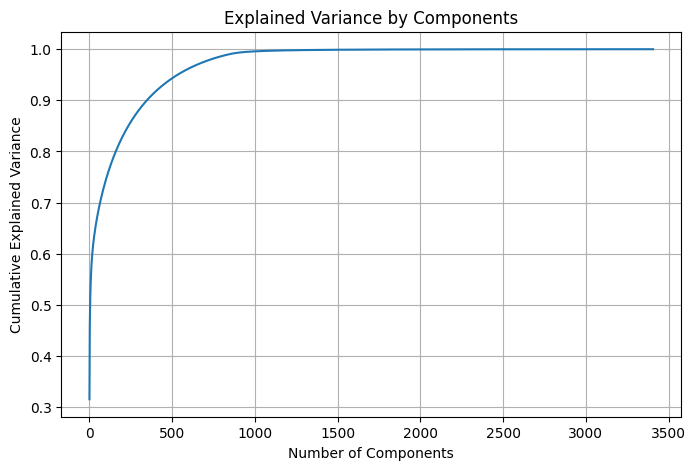

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

anomaly_data = train_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']).copy()

feat_names = anomaly_data.columns

# features_scaled = scaler.fit_transform(anomaly_data)  # your feature columns


# Assuming tfidf_matrix is your feature matrix
pca = PCA().fit(anomaly_data)

# Plotting the cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.grid(True)
plt.show()

# # Determine the number of components to use based on the plot

n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) > 0.95) + 1  # e.g., 85% variance

# # Now fit PCA with the determined optimal number of components
# pca_optimal = PCA(n_components=n_components)
# pca_features_optimal = pca_optimal.fit_transform(tfidf_matrix.toarray())


In [29]:
anomaly_data.head()

paragraph_count  sentence_count  word_count  avg_paragraph_length  \
0         1.202499        0.452698    0.211184             -0.827554   
1         0.007954        0.337320   -0.361915             -0.491664   
2         0.007954        0.914208    2.230357              0.932003   
3         0.007954        0.568075    1.070832              0.295196   
4        -1.186591       -0.585701   -0.708440              3.153511   

   max_paragraph_length  min_paragraph_length  avg_sentence_length  \
0             -0.874042             -0.619015            -0.274704   
1             -0.690468             -0.280600            -0.472872   
2              0.456868              1.174582             0.274684   
3              0.288592             -0.094473             0.020801   
4              2.001947              3.526562            -0.190636   

   max_sentence_length  min_sentence_length  avg_word_length  max_word_length  \
0            -0.488211             0.040339        -1.008314        -0.841577   
1            -0.839229            -0.098958         0.494014        -0.308687   
2             1.179123            -0.029310        -0.486418         0.224202   
3             0.169947            -0.029310         1.087597         1.023537   
4            -0.312703            -0.307904         0.394809        -0.042242   

   min_word_length  flesch_reading_ease  gunning_fog_index  sentiment_score  \
0        -0.051236             0.618749          -0.476019           0.9959   
1        -0.051236             0.258498          -0.368291          -0.6369   
2        -0.051236            -0.430115           0.164362           0.9953   
3        -0.051236            -0.271361           0.313983           0.9439   
4        -0.051236            -0.023731           0.042669           0.9613   

   full_text_ngram_embedding_0  full_text_ngram_embedding_1  \
0                     0.345207                     1.087958   
1                     0.598683                     0.646034   
2                    -0.027379                     0.747184   
3                    -0.019641                     0.747356   
4                    -0.108733                     0.492435   

   full_text_ngram_embedding_2  full_text_ngram_embedding_3  \
0                     0.248871                    -0.099822   
1                     0.534663                    -0.142159   
2                     0.368529                    -0.577695   
3                     0.665691                     0.102258   
4                     0.361342                    -0.686971   

   full_text_ngram_embedding_4  full_text_ngram_embedding_5  \
0                    -0.379308                    -1.159477   
1                    -0.047769                    -0.788072   
2                    -0.150243                    -0.968747   
3                     0.078997                    -1.426543   
4                    -0.067436                    -0.982724   

   full_text_ngram_embedding_6  full_text_ngram_embedding_7  \
0                     0.929570                     1.161029   
1                     1.205296                     1.399984   
2                     0.552766                     1.398263   
3                     1.028657                     1.321481   
4                     0.473286                     1.484891   

   full_text_ngram_embedding_8  full_text_ngram_embedding_9  \
0                    -0.920834                    -0.698089   
1                    -0.540951                    -0.509434   
2                    -0.750934                    -0.652362   
3                    -0.345762                    -0.609318   
4                    -0.847379                    -0.532201   

   full_text_ngram_embedding_10  full_text_ngram_embedding_11  \
0                      0.365566                     -0.867946   
1                      0.247978                     -0.962546   
2                      0.862854                     -1.018004   
3                      0.722852 

In [30]:

from sklearn.ensemble import IsolationForest


iso_forest_best = IsolationForest(bootstrap=True, contamination=0.2, max_samples='auto',
                n_estimators=10, max_features=1, random_state=42)

# Fit the model to the training data
iso_forest_best.fit(anomaly_data)

# Predict anomalies (outliers)
train_anomalies = iso_forest_best.predict(anomaly_data)

val_anomalies = iso_forest_best.predict(validation_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

test_anomalies = iso_forest_best.predict(test_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))



# save iso_forest_best model

import dill

with open('/home/jack/github/kaggle/scoring/model_data/sklearn/iso_forest_best.pkl', 'wb') as f:

    dill.dump(iso_forest_best, f)



/home/jack/envs/scoring/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [31]:

anamolies = pd.DataFrame()
anamolies['anomaly'] = train_anomalies
anamolies['target'] = train_merged['score']

# Compare anomaly distribution to target classes
anomaly_distribution = anamolies.groupby(['target', 'anomaly']).size().unstack(fill_value=0)
print(anomaly_distribution)

anomaly   -1     1
target            
0        251   550
1        477  2545
2        595  3424
3        585  1928
4        246   375
5         61    39


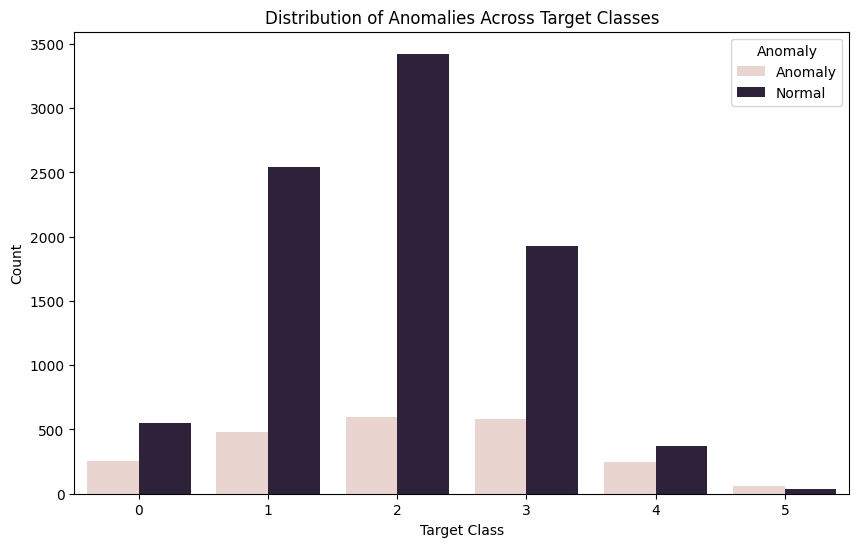

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of anomalies across different classes
plt.figure(figsize=(10, 6))
sns.countplot(x='target', hue='anomaly', data=anamolies)
plt.title('Distribution of Anomalies Across Target Classes')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.legend(title='Anomaly', labels=['Anomaly', 'Normal'])
plt.show()

In [33]:
train_merged['anomaly'] = train_anomalies

validation_merged['anomaly'] = val_anomalies

test_merged['anomaly'] = test_anomalies

In [34]:
# Scale features

# Applying PCA
pca = PCA(n_components=n_components)  # Reduce to 50 dimensions

pca_features_train = pca.fit_transform(train_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

pca_features_val = pca.transform(validation_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

pca_features_test = pca.transform(test_merged.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered', 'score']))

# Applying t-SNE
tsne = TSNE(n_components=2, learning_rate='auto', init='random')  # Reduce to 2 dimensions

tsne_features_train = tsne.fit_transform(pca_features_train)  # It's common to apply t-SNE after PCA

tsne_features_val = tsne.fit_transform(pca_features_val)

tsne_features_test = tsne.fit_transform(pca_features_test)


# Add reduced features to DataFrame

for i in range(pca_features_train.shape[1]):
    train_merged[f'pca_feature{i+1}'] = pca_features_train[:, i]
    validation_merged[f'pca_feature{i+1}'] = pca_features_val[:, i]
    test_merged[f'pca_feature{i+1}'] = pca_features_test[:, i]


    
train_merged['tsne_feature1'], train_merged['tsne_feature2'] = tsne_features_train[:, 0], tsne_features_train[:, 1]

validation_merged['tsne_feature1'], validation_merged['tsne_feature2'] = tsne_features_val[:, 0], tsne_features_val[:, 1]

test_merged['tsne_feature1'], test_merged['tsne_feature2'] = tsne_features_test[:, 0], tsne_features_test[:, 1]



# save pca and tsne models

with open('/home/jack/github/kaggle/scoring/model_data/sklearn/pca_model.pkl', 'wb') as f:

    dill.dump(pca, f)

with open('/home/jack/github/kaggle/scoring/model_data/sklearn/tsne_model.pkl', 'wb') as f:

    dill.dump(tsne, f)




In [ ]:
pca_tsne_columns = [col for col in train_merged.columns if 'pca_feature' in col or 'tsne_feature' in col]

pca_df_train = train_merged[pca_tsne_columns]

pca_df_val = validation_merged[pca_tsne_columns]

pca_df_test = test_merged[pca_tsne_columns]



train_merged.drop(columns=pca_tsne_columns, inplace=True)

validation_merged.drop(columns=pca_tsne_columns, inplace=True)

test_merged.drop(columns=pca_tsne_columns, inplace=True)



In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming df is your DataFrame with 3000 features
# Calculate summary statistics
summary_stats = anomaly_data.describe().T  # Transpose to get features as rows

# Creating a heatmap of the summary statistics
sns.heatmap(summary_stats[['mean', '50%', 'std']], cmap='viridis')


In [ ]:
# Calculate the correlation matrix
corr_matrix = anomaly_data.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, cmap='coolwarm')


In [ ]:
import plotly.express as px

# Randomly select 30 features to visualize
sampled_columns = np.random.choice(anomaly_data.columns, 30, replace=False)
fig = px.histogram(anomaly_data, x=sampled_columns, facet_col_wrap=5)  # Adjust layout accordingly
fig.show()


In [ ]:
# Drop anomolies from the training data

train_merged = train_merged[train_merged['anomaly'] == 1]

train_merged.drop(columns=['anomaly'], inplace=True)

validation_merged = validation_merged[validation_merged['anomaly'] == 1]

validation_merged.drop(columns=['anomaly'], inplace=True)

test_merged = test_merged[test_merged['anomaly'] == 1]

test_merged.drop(columns=['anomaly'], inplace=True)

train_merged.head()

In [ ]:
# from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
# from sklearn.cluster import KMeans


# features_scaled = scaler.fit_transform(anomaly_data)  # your feature columns

# # Cluster the data
# kmeans = KMeans(n_clusters=6, random_state=42)

# # df['clusters'] = kmeans.fit_predict(pca_features)

# train_merged['clusters'] = kmeans.fit_predict(features_scaled)

# # Calculate metrics
# ari_score = adjusted_rand_score(df['score'], df['clusters'])

# nmi_score = normalized_mutual_info_score(df['score'], df['clusters'])

# print(f"Adjusted Rand Index: {ari_score:.4f}")
# print(f"Normalized Mutual Information: {nmi_score:.4f}")


In [ ]:
# import seaborn as sns
# sns.countplot(x='clusters', hue='score', data=df)

In [ ]:
# from sklearn.ensemble import IsolationForest

# # Fit an Isolation Forest for each cluster using PCA features

# for cluster in df['clusters'].unique():
#     subset = df[df['clusters'] == cluster]
#     iforest = IsolationForest(n_estimators=100, contamination='auto')
#     anomaly_scores = iforest.fit_predict(subset[[f'pca_feature{i+1}' for i in range(2000)]])  # Using first 50 PCA components
#     df.loc[df['clusters'] == cluster, 'pca_anomaly_score'] = anomaly_scores

# # Normalize the anomaly scores based on cluster frequencies

# cluster_frequencies = df['clusters'].value_counts(normalize=True)

# def adjust_anomaly_score(row, score_type):
#     frequency = cluster_frequencies[row['clusters']]
#     return row[score_type] * (1 / frequency)

# df['adjusted_pca_anomaly_score'] = df.apply(lambda row: adjust_anomaly_score(row, 'pca_anomaly_score'), axis=1)

# # df['adjusted_tsne_anomaly_score'] = df.apply(lambda row: adjust_anomaly_score(row, 'tsne_anomaly_score'), axis=1)

# # save class frequencies to file

# cluster_frequencies.to_csv('/home/jack/github/kaggle/scoring/model_data/sklearn/class_frequencies.csv')


In [ ]:
# from sklearn.neighbors import NearestNeighbors

# # Calculate local density using PCA features
# nn = NearestNeighbors(n_neighbors=3)
# nn.fit(df[[f'pca_feature{i+1}' for i in range(2000)]])
# distances, _ = nn.kneighbors(df[[f'pca_feature{i+1}' for i in range(2000)]])
# df['local_density'] = 1 / distances.mean(axis=1)

In [ ]:
train = train_merged.copy()

val = validation_merged.copy()

test = test_merged.copy()


In [ ]:
train.head()

In [ ]:
len(train.columns)

In [ ]:
train.score.value_counts()

In [ ]:
# show columns with nan values greater than 0

nan_cols = train.isna().sum()

nan_cols = nan_cols[nan_cols > 0]

nan_cols    


In [ ]:
feature_cols = []

for col in train_merged.columns:
    if (col != 'essay_id') and (col != 'score') and (col != 'full_text') and (col != 'clean_text') and (col != 'lowered'):
        feature_cols.append(col) 

In [ ]:
# pd.set_option('display.max_columns', None)
# feature_cols

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = train['score'].copy()
val_labels = val['score'].copy()
test_labels = test['score'].copy()

# Extract features for scaling
train_features = train[feature_cols] # Subset with only feature columns
val_features = val[feature_cols]
test_features = test[feature_cols]


# Save the scaler for later use
with open(file_config['scaler'], 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [ ]:
pca_features_train = pca_df_train.copy()    

pca_features_val = pca_df_val.copy()

pca_features_test = pca_df_test.copy()

In [ ]:
print(train_features.shape, val_features.shape, test_features.shape)

In [ ]:
print(pca_features_train.shape, pca_features_val.shape, pca_features_test.shape)

In [ ]:
train_features.head()

In [ ]:
train_labels.head()

In [ ]:
print(train_features.shape, train_labels.shape)

In [ ]:
# feature_cols.append('anomaly')

# save the order of the column names to a txt file

with open(file_config['feature_cols'], 'w') as f:
    for item in feature_cols:
        f.write("%s\n" % item)

In [ ]:
# Check if the file has been written correctly and is not empty
import os

scaler_path = file_config['scaler']

if os.path.getsize(scaler_path) > 0:

    print(f"Scaler saved successfully in {scaler_path}.")
    
else:

    print(f"Failed to save scaler to {scaler_path}. File is empty.")

In [ ]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn import ensemble, model_selection, metrics
import numpy as np
import pickle
import os
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score
import keras_tuner

# Function to compute Quadratic Weighted Kappa
def quadratic_weighted_kappa_scorer(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

# Define the model building function for the tuner
def build_model(hp):
    model_type = hp.Choice('model_type', ['random_forest', 'gradient_boosting', 'lightgbm'])
    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log'))
    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1))
    else:  # LightGBM
        from lightgbm import LGBMClassifier
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            max_depth=hp.Int('max_depth', 3, 15),  # Tunable max_depth parameter
            min_data_in_leaf=hp.Int('min_data_in_leaf', 20, 100, step=10),  # Increases the minimum data per leaf
            min_gain_to_split=hp.Float('min_gain_to_split', 0.001, 0.1, sampling='log'),  # Ensures splits bring gains
            lambda_l1=hp.Float('lambda_l1', 0.01, 10.0, sampling='log'),  # L1 regularization
            lambda_l2=hp.Float('lambda_l2', 0.01, 10.0, sampling='log'),  # L2 regularization
            force_col_wise=True,  # Force using column-wise calculation to avoid overhead
            class_weight='balanced'  # Handling class imbalance
        )
    return model





# Prepare data: Assuming X_train and y_train are already defined
X_train_original = train_features.copy()  # Keep the original training data
y_train_original = train_labels.copy() 

# Apply SMOTE to balance the minority classes
smote = SMOTE(sampling_strategy='not minority', random_state=42)
X_train_upsampled, y_train_upsampled = smote.fit_resample(X_train_original, y_train_original)


In [ ]:
# Tuner configuration

tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=12),
    hypermodel=build_model,
    scoring=make_scorer(quadratic_weighted_kappa_scorer),
    cv=model_selection.StratifiedKFold(3),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)


# Tuning on the original data

tuner.search(X_train_original.values, y_train_original.values)

# tuner.search(X_train_upsampled.values, y_train_upsampled.values)


In [ ]:
# pca_tuner = keras_tuner.tuners.SklearnTuner(
#     oracle=keras_tuner.oracles.BayesianOptimizationOracle(
#         objective=keras_tuner.Objective('score', 'max'),
#         max_trials=12),
#     hypermodel=build_model,
#     scoring=make_scorer(quadratic_weighted_kappa_scorer),
#     cv=model_selection.StratifiedKFold(3),
#     directory='.',
#     project_name='data/sklearn/pca',
#     overwrite=True)


# # Tuning on the original data

# pca_tuner.search(pca_features_train.values, y_train_original.values)

In [ ]:
# # apply smote within k-fold cross validation in order to avoid data leakage

# # Define the cross-validation strategy

# cv = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Initialize the model
# model = ensemble.RandomForestClassifier(random_state=42)

# # Initialize the SMOTE object

# smote = SMOTE(sampling_strategy='not majority', random_state=42)

# # Initialize the StandardScaler
# scaler = StandardScaler()

# # Initialize the list to store the cross-validated scores

# cv_scores = []

# # Perform cross-validation

# for train_idx, val_idx in cv.split(X_train, y_train):

#     # Extract the training and validation data
#     X_train_fold, y_train_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

#     # Apply SMOTE to the training data
#     X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fold, y_train_fold)

#     # Scale the training and validation data
#     X_train_scaled = scaler.fit_transform(X_train_resampled)
#     X_val_scaled = scaler.transform(X_val_fold)

#     # Fit the model on the training data
#     model.fit(X_train_scaled, y_train_resampled)

#     # Predict the target on the validation data
#     y_pred = model.predict(X_val_scaled)

#     # Compute the Quadratic Weighted Kappa
#     qwk = quadratic_weighted_kappa_scorer(y_val_fold, y_pred)

#     # Append the score to the list
#     cv_scores.append(qwk)

# # Compute the average score

# cv_score = np.mean(cv_scores)

# # Print the average score

# print(f"Average Quadratic Weighted Kappa: {cv_score:.4f}")

# # Save the model

# with open(file_config['sklearn_model'], 'wb') as f:
#     pickle.dump(model, f)



In [ ]:
# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# # Fit models on both upsampled and original data
# model_standard = clone(best_model)
# model_standard.fit(X_train_original, y_train_original)

# model_upsampled = clone(best_model)
# model_upsampled.fit(X_train_upsampled, y_train_upsampled)

# # Ensemble using voting
# ensemble_model = VotingClassifier(estimators=[
#     ('standard', model_standard),
#     ('upsampled', model_upsampled)
# ], voting='soft')



In [ ]:
# Assuming X_val and y_val are your validation sets

best_model.fit(X_train_original, y_train_original)  # Optionally refit if necessary

# ensemble_model.fit(X_train_original, y_train_original)  # Optionally refit if necessary

In [ ]:
# ensamble_predictions = ensemble_model.predict(X_test.drop(columns=['essay_id']))

# # Evaluate and print results
# print("Validation Accuracy:", accuracy_score(y_test, ensamble_predictions))
# print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(y_test, ensamble_predictions))
# print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(y_test, ensamble_predictions))
# print("Validation Cohens Weighted Kappa:",cohen_kappa_score(y_test, ensamble_predictions, weights='quadratic'))

In [ ]:
predictions = best_model.predict(val_features)

# Evaluate and print results
print("Validation Accuracy:", accuracy_score(val_labels, predictions))
print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(val_labels, predictions))
print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(val_labels, predictions))
print("Validation Cohens Weighted Kappa:",cohen_kappa_score(val_labels, predictions, weights='quadratic'))

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(val_labels, predictions)

In [ ]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(val_labels, predictions))

In [ ]:
from joblib import dump, load

dump(best_model, file_config['sklearn_model'])


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(val_labels, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# combine train and val data and re train the model

train_val = pd.concat([train, val])

train_val_features = train_val[feature_cols]

train_val_labels = train_val['score']

best_model.fit(train_val_features, train_val_labels)



In [ ]:
predictions = best_model.predict(test_features)

# Evaluate and print results
print("Validation Accuracy:", accuracy_score(test_labels, predictions))
print("Validation Cohen's Kappa:", quadratic_weighted_kappa_scorer(test_labels, predictions))
print("Validation Quadratic Weighted Kappa:", quadratic_weighted_kappa_scorer(test_labels, predictions))
print("Validation Cohens Weighted Kappa:",cohen_kappa_score(test_labels, predictions, weights='quadratic'))

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(test_labels, predictions)

In [ ]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(test_labels, predictions))

In [ ]:
from joblib import dump, load

dump(best_model, file_config['sklearn_model'])


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(test_labels, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# X_test['predictions'] = predictions

# df_aggregated = X_test.groupby('essay_id')['predictions'].agg(lambda x: x.value_counts().index[0]).reset_index()

# df_aggregated.head()

In [ ]:
# import tensorflow_hub as hub
# import tensorflow as tf
# import os

# # Define the local path where the model will be saved
# model_dir = '/home/jack/github/kaggle/scoring/data/directory'

# # Ensure the directory exists
# os.makedirs(model_dir, exist_ok=True)

# # Download and save the model
# use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
# tf.saved_model.save(use_model, model_dir)


In [ ]:
# get number of features from the model

# Get the number of features from the model

best_model = load(file_config['sklearn_model'])

# Get the number of features from the model

num_features = len(best_model.feature_importances_)

# Print the number of features

print(f"Number of features: {num_features}")

In [ ]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [ ]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

In [ ]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [ ]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


In [ ]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [ ]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


In [ ]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [ ]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


In [ ]:
print(len(val_features), len(val_df), len(predictions))

In [ ]:
val_df.tail()

In [ ]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

In [ ]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


In [ ]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


In [ ]:
# load tf model
len(misclassified_text)

In [ ]:
# add full mis classified text to a txt file seperated by  '---' and a new line after every 10 words in each essay

with open('misclassified_text.txt', 'w') as f:
    for essay in misclassified_text:
        f.write("%s\n" % essay)
        f.write('---\n')
        


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming `df` has your model's features and labels
X = val_df[feature_cols]
y = val_df['score'] == val_df['Predicted_Label']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a RandomForest to see feature importances
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get the most important features
importances = clf.feature_importances_
features = feature_cols
important_features = {features[i]: importances[i] for i in range(len(features))}

# convert to percentages rounded and sort

important_features = {k: round(v, 5) for k, v in important_features.items()}

print("Most predictive features of misclassification:", sorted(important_features.items(), key=lambda x: x[1], reverse=True))

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assume val_df and feature_cols are already defined

# # Set the option to display all rows
# pd.set_option('display.max_rows', None)

# # Selecting the features and the target
# X = val_df[feature_cols]
# y = val_df['score']

# # Calculate the correlation between features and the target
# corr = X.corrwith(y)

# # Sort the correlation values
# corr = corr.sort_values(ascending=False)

# # Convert the Series to a DataFrame for heatmap compatibility
# corr_df = pd.DataFrame(corr, columns=['Correlation'])

# corr_df


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Define the feature set with and without the specific features
# X_with = val_df[feature_cols]  # including all features
# X_without = val_df.drop(columns=['misspelling_count', 'sentence_length'], axis=1) # excluding problematic features

# y = val_df['score']  # target variable

# # Split the data
# X_train_with, X_test_with, y_train, y_test = train_test_split(X_with, y, test_size=0.3, random_state=42)
# X_train_without, X_test_without, _ , _ = train_test_split(X_without, y, test_size=0.3, random_state=42)

# # Train models
# model_with = RandomForestClassifier().fit(X_train_with, y_train)
# model_without = RandomForestClassifier().fit(X_train_without, y_train)

# # Evaluate models
# print("With features:")
# print(classification_report(y_test, model_with.predict(X_test_with)))

# print("Without features:")
# print(classification_report(y_test, model_without.predict(X_test_without)))
